# Benchmark workflow — UCB-GLOBES atmospheric tracers
Compounds from `UCB_GLOBES_ID_NotInNIST_toHilda_2026.04.16.xlsx`.

**Section 0** (unique to this notebook) handles all UCB-GLOBES-specific
preparation: de-duplication, SMILES lookup, TMS derivatisation, EXP spectra
from the embedded X/Y-Values, and SI table generation.
Sections 1–9 then follow the standard benchmark template.

## How to use
1. Edit the **CONFIG** cell.
2. Run Section 0 once to prepare all data.
3. Run Sections 2–5 to submit simulation jobs.
4. Run Sections 7–9 after jobs finish.

In [1]:
import os, sys, subprocess
from pathlib import Path
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))

from src.workflow.job_submission import (
    submit_slurm_array, submit_qcxms_frag_jobs, run_plotms_for_included,
    submit_crest_jobs, submit_qcxms2_jobs, submit_cfmid_job,
    write_cfmid_idx_smiles, check_crest_status,
)
from src.processing.process_spectra_batch import process_spectra_batch
from src.analysis.run_comparison import run_comparison
from src.analysis.diagnose_spectra import diagnose_spectra

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CONFIG — edit only this cell                                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

DATASET_NAME = "ucb_globes_tracers"

# Path to the UCB-GLOBES Excel file
UCB_EXCEL = "../data/raw/UCB_globes_tracers/UCB_GLOBES_ID_NotInNIST_toHilda_2026.04.16.xlsx"

# Path to TMS derivatisation script (needed for Format-B common-name compounds)
DERIV_SCRIPT = "../src/processing/make_TMS_derivative_251125_v1.py"

# ── Methods to run ──────────────────────────────────────────────────────────
RUN_QCXMS  = True
RUN_QCXMS2 = True
RUN_QCXMS2_DFT = False
RUN_NEIMS = True
RUN_CFMID  = True
FORCE_FRAG = True

QCXMS_VARIANTS = ["QCxMS_10_ps"]

# ── Advanced ────────────────────────────────────────────────────────────────
GSMD_ARRAY_SPECS   = {}
CREST_STUCK_FOLDERS = []
N_MOLS             = None   # auto-detected after Section 0
COMPILE_ONLY       = True
COMPILE_METHODS    = None

In [3]:
# ── Derived paths — no editing needed ──────────────────────────────────────
SRC_ROOT      = os.path.abspath("../src")
DATA_ROOT     = os.path.abspath("../data")
REPORTS_DIR   = os.path.abspath(f"../reports/{DATASET_NAME}")

PROCESSED_DIR = f"{DATA_ROOT}/processed/{DATASET_NAME}"
SIM_BASE      = f"{DATA_ROOT}/simulation_results/{DATASET_NAME}"
INPUT_CSV     = f"{PROCESSED_DIR}/{DATASET_NAME}.csv"
SMILES_COL_SIM = "Modified_SMILES"

METHODS = (
    (QCXMS_VARIANTS             if RUN_QCXMS      else [])
  + (["QCxMS2"]                 if RUN_QCXMS2     else [])
  + (["QCxMS2_dft"]             if RUN_QCXMS2_DFT else [])
  + (["NEIMS"]                  if RUN_NEIMS       else [])
  + (["CFMID"]                  if RUN_CFMID       else [])
)
_effective_methods = COMPILE_METHODS if COMPILE_METHODS is not None else METHODS

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(SIM_BASE,      exist_ok=True)
os.makedirs(REPORTS_DIR,   exist_ok=True)

print(f"Dataset:    {DATASET_NAME}")
print(f"Input CSV:  {INPUT_CSV}  (exists: {os.path.exists(INPUT_CSV)})")
print(f"Sim base:   {SIM_BASE}")
print(f"Reports:    {REPORTS_DIR}")
print(f"Methods:    {_effective_methods}")

Dataset:    ucb_globes_tracers
Input CSV:  /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/processed/ucb_globes_tracers/ucb_globes_tracers.csv  (exists: True)
Sim base:   /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/ucb_globes_tracers
Reports:    /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/reports/ucb_globes_tracers
Methods:    ['QCxMS_10_ps', 'QCxMS2', 'NEIMS', 'CFMID']


## 0. UCB-GLOBES data preparation
Runs `prepare_ucb_benchmark.py` which:
- De-duplicates by formula + cosine similarity
- Collapses stereoisomer pairs (cosine ≥ 0.90) to one entry
- Excludes ambiguous isomers (cosine < 0.90), mixtures, uncertain structures
- Looks up parent SMILES via PubChem; derivatises Format-B compounds
- Writes `EXP/` spectra folders from embedded X/Y-Values
- Writes SI LaTeX table and benchmark CSV

> Re-run with `--skip_smiles` for a fast test (no PubChem calls).

In [4]:
# Run preparation script (internet access required for PubChem lookups)
prep_script = os.path.abspath(f"{SRC_ROOT}/processing/prepare_ucb_benchmark.py")

result = subprocess.run(
    [
        "python", prep_script,
        "-i",               os.path.abspath(UCB_EXCEL),
        "-o",               SIM_BASE,
        "--processed_dir",  PROCESSED_DIR,
        "--reports_dir",    REPORTS_DIR,
        "--dataset_name",   DATASET_NAME,
        "--deriv_script",   os.path.abspath(DERIV_SCRIPT),
    ],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE,
)
print(result.stdout.decode())
if result.stderr.decode().strip():
    print("STDERR:", result.stderr.decode())

Loaded 31 entries

Classifying entries ...
  Kept: 14   Dropped/collapsed: 17
  LDY-9773       4-((1S,2R)-3,3-dimethyl-2-(3-oxobutyl)cyclobutyl)p
  LDY-9774       trimethylsilyl 4-((1S,2R)-3,3-dimethyl-2-(3-oxo-3-  [ambiguous_isomer]
  LDY-9775       trimethylsilyl 4-((1S,2R)-3,3-dimethyl-2-(3-oxobut  [duplicate_of:LDY-10849]
  LDY-9776       4-((1S,2R)-3,3-dimethyl-2-(3-oxobutyl)cyclobutyl)-
  LDY-9777       trimethylsilyl 4-((1S,2R)-3,3-dimethyl-2-(3-oxobut  [duplicate_of:LDY-21213]
  LDY-9778       trimethylsilyl 4-((1S,2R)-3,3-dimethyl-2-(3-oxobut  [stereo_of:LDY-21213]
  LDY-9808       trimethylsilyl 4-((1S,2R)-3,3-dimethyl-2-(3-oxobut  [duplicate_of:LDY-10849]
  LDY-9967       4-((1S,2R)-3,3-dimethyl-2-(3-oxobutyl)cyclobutyl)p  [duplicate_of:LDY-9773]
  LDY-10808      trimethylsilyl 4-((1S,2R)-3,3-dimethyl-2-(3-oxobut  [duplicate_of:LDY-21213]
  LDY-10849      beta-caryophyllonic acid, TMS
  LDY-21118      pinic acid, 2 TMS  [stereo_of:LDY-21352]
  LDY-21121      2- and 3-hydroxy

In [5]:
# Show benchmark compound table
if os.path.exists(INPUT_CSV):
    bench = pd.read_csv(INPUT_CSV)
    N_MOLS = len(bench)
    print(f"{N_MOLS} compounds in benchmark set")
    display(bench[["Index", "UID", "Name", "Modified_SMILES", "Total_Replacements"]]
            .fillna("").to_string(index=False))
else:
    print(f"Benchmark CSV not found: {INPUT_CSV}")
    print("Run the preparation cell above first.")

13 compounds in benchmark set


' Index        UID                                                            Name                                              Modified_SMILES  Total_Replacements\n     0   LDY-9773    4-((1S,2R)-3,3-dimethyl-2-(3-oxobutyl)cyclobutyl)pent-4-enal                               O=CCCC(=C)C1CC(C)(C)C1CCC(C)=O                   0\n     1   LDY-9776  4-((1S,2R)-3,3-dimethyl-2-(3-oxobutyl)cyclobutyl)-4-oxobutanal                               O=CCCC(=O)C1CC(C)(C)C1CCC(C)=O                   0\n     2  LDY-10849                                   beta-caryophyllonic acid, TMS                 C[Si](C)(C)OC(=O)CCC(=C)C1CC(C)(C)C1CCC(C)=O                   1\n     3  LDY-21122                                                    MBTCA, 3 TMS  C[Si](C)(C)OC(=O)CC(C)(CC(=O)O[Si](C)(C)C)C(=O)O[Si](C)(C)C                   3\n     4  LDY-21130                                      Tricarballylic acid, 3 TMS     C[Si](C)(C)OC(=O)CC(CC(=O)O[Si](C)(C)C)C(=O)O[Si](C)(C)C                   3\n     5  LDY-211

6 mirror plot(s):
  mirror_LDY-21118_LDY-21352.png


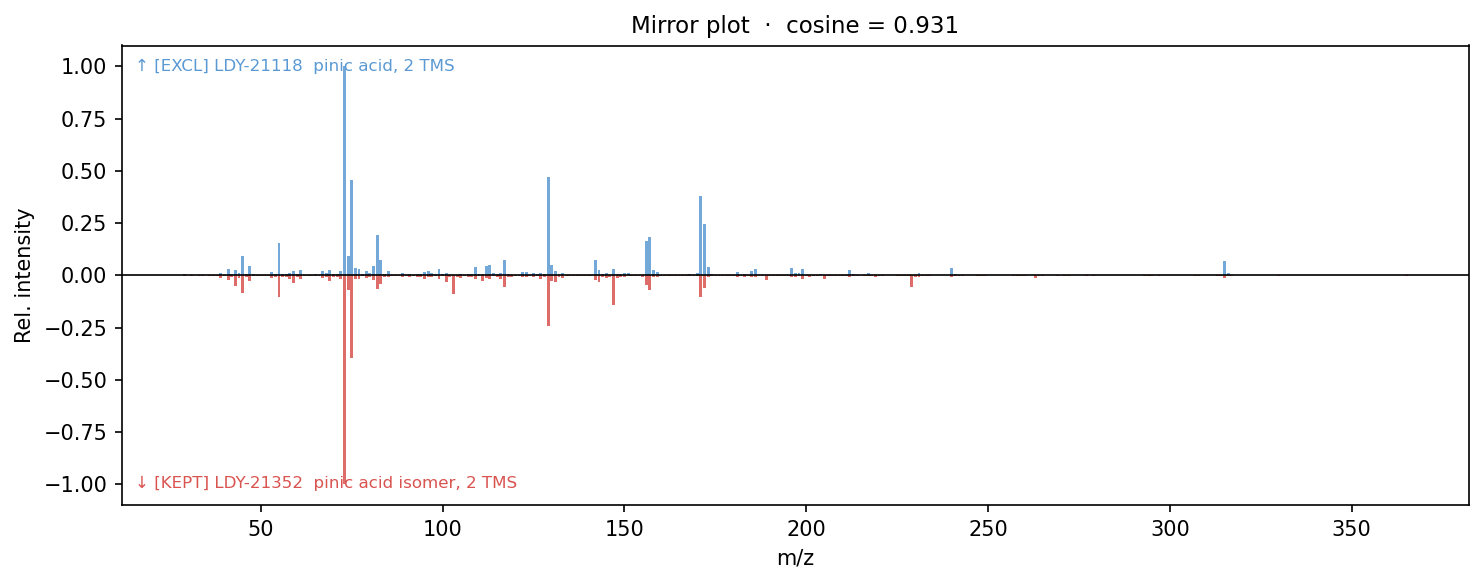

  mirror_LDY-21128_LDY-21122.png


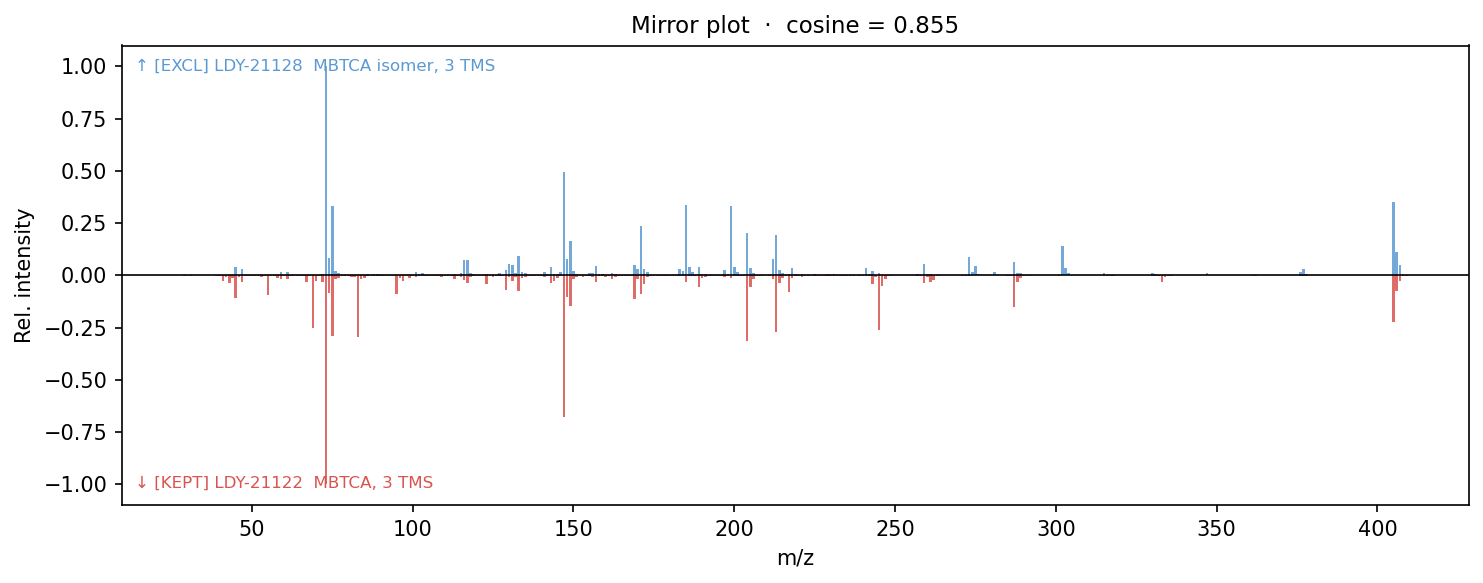

  mirror_LDY-21132_LDY-21158.png


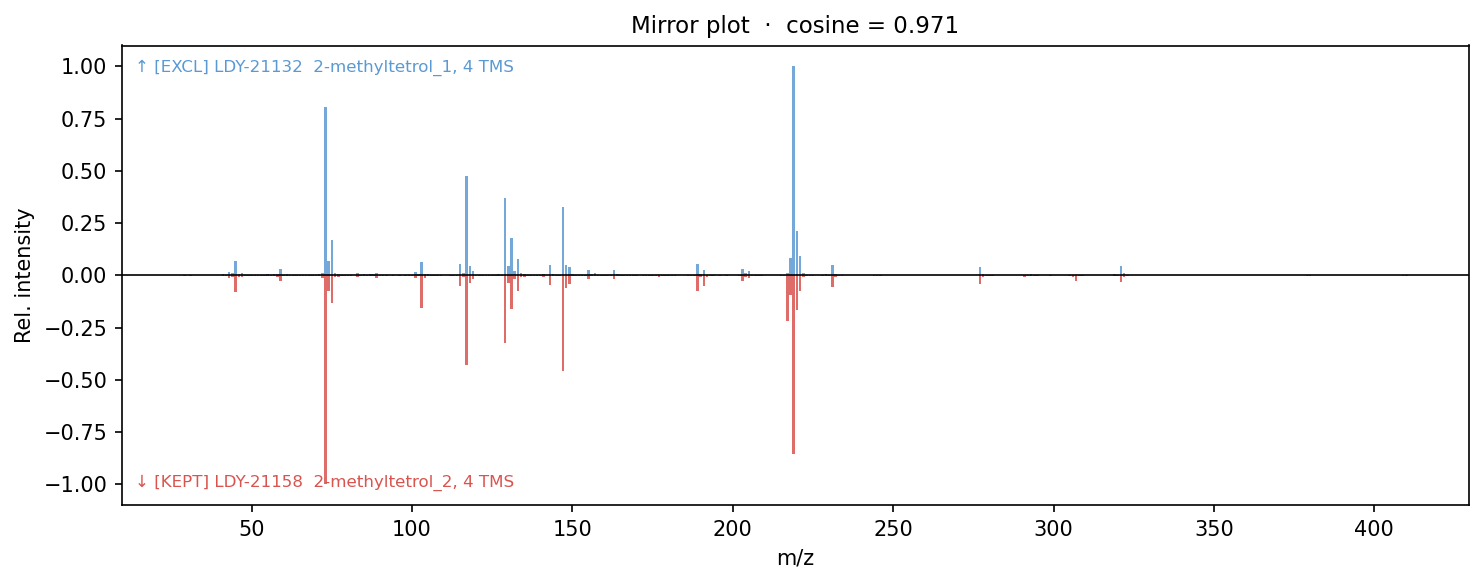

  mirror_LDY-21198_LDY-21228.png


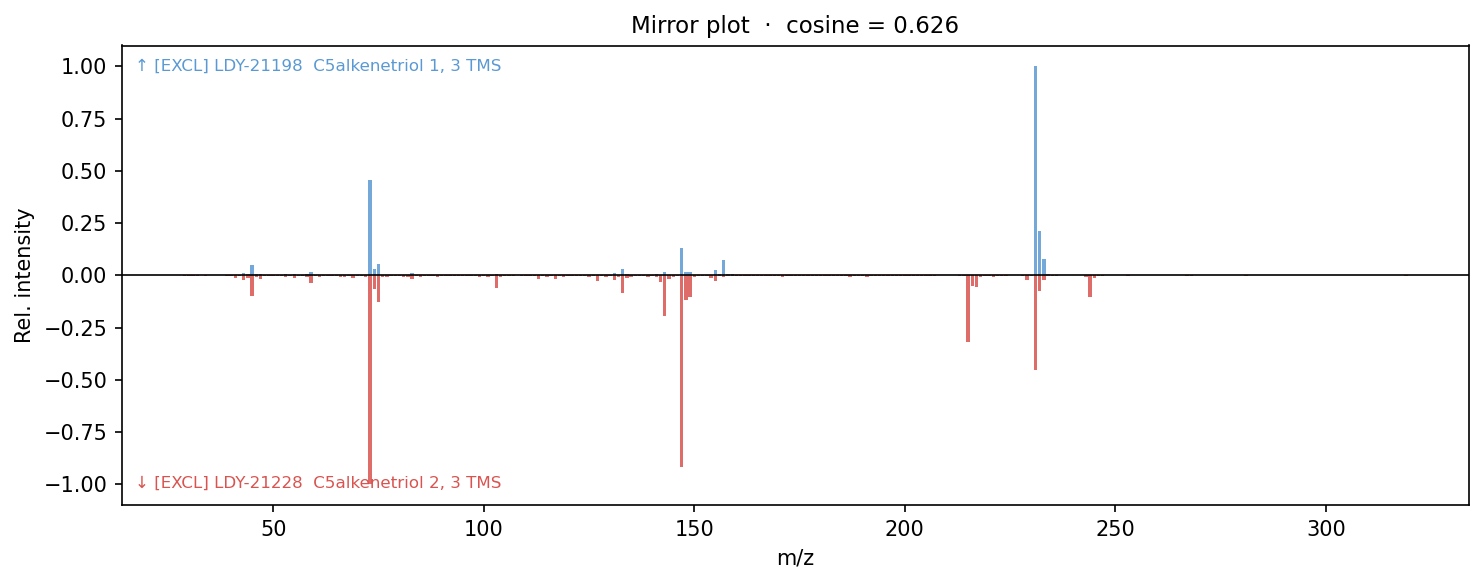

  mirror_LDY-9774_LDY-21686.png


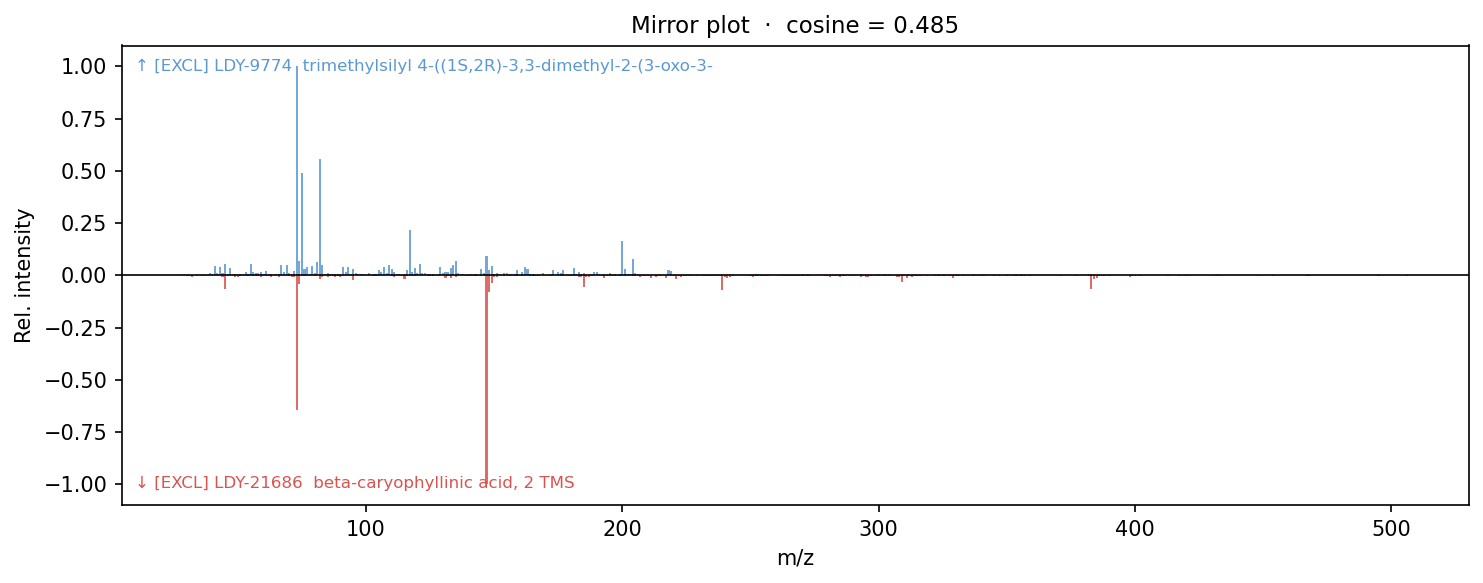

  mirror_LDY-9778_LDY-21213.png


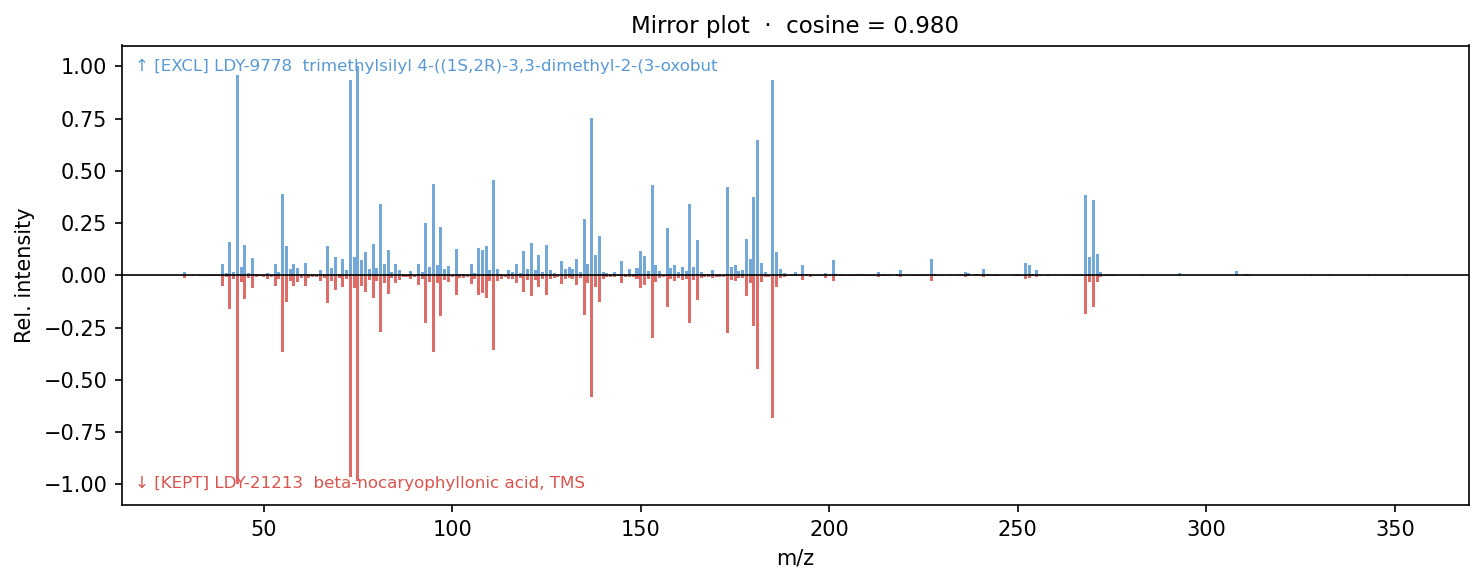

In [6]:
# Show mirror plots for isomer/duplicate pairs (saved by prepare_ucb_benchmark.py)
import glob
from IPython.display import Image, display as ipy_display

mirror_dir = Path(REPORTS_DIR) / "mirror_plots"
mirror_files = sorted(mirror_dir.glob("*.png")) if mirror_dir.exists() else []

if mirror_files:
    print(f"{len(mirror_files)} mirror plot(s):")
    for p in mirror_files:
        print(f"  {p.name}")
        ipy_display(Image(str(p), width=700))
else:
    print("No mirror plots found — run preparation cell first.")

In [7]:
import re                                                                                                        
from rdkit import Chem                                                                                           
from rdkit.Chem import Descriptors                                                                               

bench   = pd.read_csv(INPUT_CSV)                                                                                 
ucb_df  = pd.read_excel(os.path.abspath(UCB_EXCEL), engine='openpyxl')
uid_mw  = dict(zip(ucb_df['UID'], ucb_df['MW']))                                                                 

def expected_tms(name):                                                                                          
  m = re.search(r',\s*(\d+)\s*TMS\s*$', name, re.IGNORECASE)
  if m: return int(m.group(1))                                                                                 
  if re.search(r',\s*TMS\s*$', name, re.IGNORECASE): return 1
  if re.match(r'trimethylsilyl', name, re.IGNORECASE): return None  # already derivatised, count unknown       
  return 0                                                                                                     

def rdkit_mw(smi):                                                                                               
  if not smi or str(smi) in ('nan', ''): return None
  mol = Chem.MolFromSmiles(str(smi))                                                                           
  return round(Descriptors.ExactMolWt(mol), 2) if mol else None                                                

bench['Expected_TMS']   = bench['Name'].apply(expected_tms)                                                      
bench['TMS_ok']         = bench.apply(
  lambda r: True if pd.isna(r['Expected_TMS'])
            else (False if pd.isna(r.get('Total_Replacements'))
            else int(r['Total_Replacements']) == int(r['Expected_TMS'])),                               
  axis=1)                                                                                                      
bench['has_SMILES']     = bench['Modified_SMILES'].notna() & (bench['Modified_SMILES'].astype(str) != '')        
bench['MW_excel']       = bench['UID'].map(uid_mw)                                                               
bench['MW_computed']    = bench['Modified_SMILES'].apply(rdkit_mw)
bench['MW_delta']       = (bench['MW_computed'] - bench['MW_excel']).abs().round(2)                              

print(f"Compounds with SMILES : {bench['has_SMILES'].sum()} / {len(bench)}")                                     
print(f"TMS count correct     : {bench['TMS_ok'].sum()} / {bench['Expected_TMS'].notna().sum()} (Format-B only)")
print(f"MW within 1 Da        : {(bench['MW_delta'] < 1).sum()} / {bench['MW_delta'].notna().sum()}")            
print()                                                                                                          

# per-group TMS breakdown (keep only columns present in CSV)
tms_cols = [c for c in ['OH','COOH','SH','Primary_Amine','Secondary_Amine','Imine','OOH']
            if c in bench.columns]

cols = ['Index','UID','Name','Total_Replacements','Expected_TMS','TMS_ok',
        *tms_cols, 'MW_excel','MW_computed','MW_delta','has_SMILES']
print(bench[cols].to_string(index=False))

if tms_cols:
    print('\nTMS replacements by functional group:')
    print(bench[tms_cols].apply(pd.to_numeric, errors='coerce').sum().to_string()) 

Compounds with SMILES : 13 / 13
TMS count correct     : 13 / 13 (Format-B only)
MW within 1 Da        : 9 / 13

 Index        UID                                                            Name  Total_Replacements  Expected_TMS  TMS_ok   OH  COOH   SH  Primary_Amine  Secondary_Amine  Imine  OOH  MW_excel  MW_computed  MW_delta  has_SMILES
     0   LDY-9773    4-((1S,2R)-3,3-dimethyl-2-(3-oxobutyl)cyclobutyl)pent-4-enal                   0             0    True  NaN   NaN  NaN            NaN              NaN    NaN  NaN  236.3526       236.18      0.17        True
     1   LDY-9776  4-((1S,2R)-3,3-dimethyl-2-(3-oxobutyl)cyclobutyl)-4-oxobutanal                   0             0    True  NaN   NaN  NaN            NaN              NaN    NaN  NaN  238.3248       238.16      0.16        True
     2  LDY-10849                                   beta-caryophyllonic acid, TMS                   1             1    True  0.0   1.0  0.0            0.0              0.0    0.0  0.0  324.0000       3

<Figure size 1440x1080 with 0 Axes>

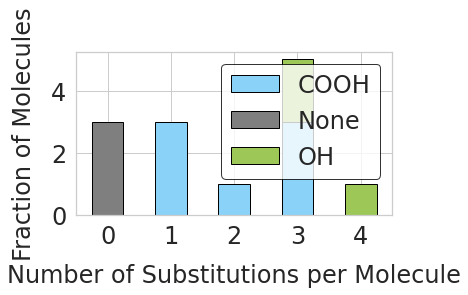

In [8]:
# TMS substitution histogram (same plot as Franklin workflow)
import importlib.util, sys as _sys

_deriv_spec = importlib.util.spec_from_file_location(
    'make_TMS_derivative',
    os.path.join(SRC_ROOT, 'processing', 'make_TMS_derivative_251125_v1.py'))
_deriv_mod = importlib.util.module_from_spec(_deriv_spec)
_deriv_spec.loader.exec_module(_deriv_mod)

bench_tms = pd.read_csv(INPUT_CSV)
# Rename columns to match what plot_substitutions expects
_col_map = {'Primary_Amine': 'Primary Amine', 'Secondary_Amine': 'Secondary Amine'}
bench_plot = bench_tms.rename(columns=_col_map)
_tms_cols = ['OH','SH','Secondary Amine','Primary Amine','Imine','OOH','COOH']
_present  = [c for c in _tms_cols if c in bench_plot.columns]
if _present:
    _deriv_mod.plot_substitutions(bench_plot)
else:
    print('No per-group TMS columns found in CSV — re-run Section 0 prepare cell first.')


## 1. Data preparation
De-duplication and TMS derivatisation are handled by Section 0.
This cell just verifies the benchmark CSV is ready and detects N_MOLS.

In [9]:
if not os.path.exists(INPUT_CSV):
    raise FileNotFoundError(f"{INPUT_CSV} — run Section 0 first.")

if N_MOLS is None:
    N_MOLS = len(pd.read_csv(INPUT_CSV))

print(f"Input CSV : {INPUT_CSV}")
print(f"N_MOLS    : {N_MOLS}")
print(f"SMILES col: {SMILES_COL_SIM}")

Input CSV : /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/processed/ucb_globes_tracers/ucb_globes_tracers.csv
N_MOLS    : 13
SMILES col: Modified_SMILES


## 2. QCxMS — directory setup, GS-MD, fragmentation & PlotMS

In [10]:
if RUN_QCXMS and not COMPILE_ONLY:
    for variant in QCXMS_VARIANTS:
        !python {SRC_ROOT}/processing/make_directories_and_sdfs.py \
            --input_csv   {INPUT_CSV} \
            --output_root {SIM_BASE}/{variant}

In [11]:
if RUN_QCXMS and not COMPILE_ONLY:
    GSMD_SCRIPTS = {
        "QCxMS_10_ps": "submit_qcxms_gs_md_10_ps.sh",
        "QCxMS_25_ps": "submit_qcxms_gs_md_25_ps.sh",
    }
    for variant in QCXMS_VARIANTS:
        print(f"\n--- {variant} ---")
        submit_slurm_array(
            sim_dir     = f"{SIM_BASE}/{variant}",
            script_path = f"{SRC_ROOT}/workflow/{GSMD_SCRIPTS[variant]}",
            array_spec  = GSMD_ARRAY_SPECS.get(variant, f"0-{N_MOLS - 1}"),
            done_marker = "GS-opt/MS-run/TMPQCXMS",
            n_mols      = N_MOLS,
        )

In [12]:
if RUN_QCXMS and not COMPILE_ONLY:
    for variant in QCXMS_VARIANTS:
        print(f"\n--- {variant} ---")
        submit_qcxms_frag_jobs(
            sim_dir     = f"{SIM_BASE}/{variant}",
            script_path = os.path.abspath(f"{SRC_ROOT}/workflow/submit_qcxms_frag_serial_no_unity.sh"),
            n_mols      = N_MOLS,
            skip_done_check = FORCE_FRAG,
        )

In [13]:
print(N_MOLS)

13


In [14]:
# Check how many trajectories finished (reads stdout of check_qcxms_runs.sh)
if RUN_QCXMS:
    check_script = os.path.abspath(f"{SRC_ROOT}/utils/check_qcxms_runs.sh")
    for variant in QCXMS_VARIANTS:
        print(f"\n=== {variant} ===")
        subprocess.run(["sh", check_script], cwd=f"{SIM_BASE}/{variant}")


=== QCxMS_10_ps ===


In [15]:
if RUN_QCXMS:
    for variant in QCXMS_VARIANTS:
        print(f"\n--- {variant} ---")
        run_plotms_for_included(wrkdir=f"{SIM_BASE}/{variant}")


--- QCxMS_10_ps ---
Folders to process (1): ['0009']
[REDO] 0009: prior run below quality (1066 runs, base peak 276) — re-running
Running PlotMS for 0009 (1300/1300 trajectories)...
  Done [LOW QUALITY] — 1066 runs, base peak 276


## 3. QCxMS2 — CREST conformer search & fragmentation

In [16]:
if RUN_QCXMS2 and not COMPILE_ONLY:
    !python {SRC_ROOT}/processing/make_directories_and_sdfs.py \
        --input_csv   {INPUT_CSV} \
        --output_root {SIM_BASE}/QCxMS2

In [17]:
if RUN_QCXMS2 and not COMPILE_ONLY:
    folders = CREST_STUCK_FOLDERS if CREST_STUCK_FOLDERS else [
        f"{i:04d}" for i in range(N_MOLS)
    ]
    submit_crest_jobs(
        sim_dir     = f"{SIM_BASE}/QCxMS2",
        script_path = os.path.abspath(f"{SRC_ROOT}/workflow/submit_batch_crest.sh"),
        folders     = folders,
    )

In [18]:
if RUN_QCXMS2:
    check_crest_status({DATASET_NAME: f"{SIM_BASE}/QCxMS2"})


Dataset: ucb_globes_tracers
  Finished:        13 — ['0000', '0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012']
  Still running:    0 — []
  Not done/stuck:   0 — []
  Missing dir:     48 — ['0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020', '0021', '0022', '0023', '0024', '0025', '0026', '0027', '0028', '0029', '0030', '0031', '0032', '0033', '0034', '0035', '0036', '0037', '0038', '0039', '0040', '0041', '0042', '0043', '0044', '0045', '0046', '0047', '0048', '0049', '0050', '0051', '0052', '0053', '0054', '0055', '0056', '0057', '0058', '0059', '0060']


In [19]:
if RUN_QCXMS2 and not COMPILE_ONLY:
    submit_qcxms2_jobs(
        base_dir    = f"{SIM_BASE}/QCxMS2",
        bash_script = os.path.abspath(f"{SRC_ROOT}/workflow/submit_qcxms2_job.sh"),
        num_folders = N_MOLS,
    )

## 3b. QCxMS2_dft — wB97X-3c refinement

Uses the same CREST conformer output as QCxMS2, with recommended mixed-level settings:
GFN2-xTB for geometry and IP prescreening; wB97X-3c for barriers and IP refinement.

In [20]:
if RUN_QCXMS2_DFT and not COMPILE_ONLY:
    from src.workflow.job_submission import submit_qcxms2_jobs
    import shutil
    dft_base = f"{SIM_BASE}/QCxMS2_dft"
    qcxms2_base = f"{SIM_BASE}/QCxMS2"
    # Set up mol dirs and copy crest_best.xyz from QCxMS2
    for mol_id in [f"{i:04d}" for i in range(N_MOLS)]:
        src_xyz = Path(qcxms2_base) / mol_id / "crest_best.xyz"
        dst_dir = Path(dft_base) / mol_id
        if not src_xyz.exists():
            continue
        dst_dir.mkdir(parents=True, exist_ok=True)
        if not (dst_dir / "crest_best.xyz").exists():
            shutil.copy2(src_xyz, dst_dir / "crest_best.xyz")
        for log in ("crest.log", "crest_restart.log"):
            src_log = Path(qcxms2_base) / mol_id / log
            if src_log.exists() and not (dst_dir / log).exists():
                shutil.copy2(src_log, dst_dir / log)
    submit_qcxms2_jobs(
        base_dir       = dft_base,
        bash_script    = os.path.abspath(f"{SRC_ROOT}/workflow/submit_qcxms2_dft_job.sh"),
        method         = "wb97x3c",
        num_folders    = N_MOLS,
    )

## 4. NEIMS

In [21]:
if RUN_NEIMS and not COMPILE_ONLY:
    !python {SRC_ROOT}/processing/make_directories_and_sdfs.py \
        --input_csv   {INPUT_CSV} \
        --output_root {SIM_BASE}/NEIMS
    submit_slurm_array(
        sim_dir     = f"{SIM_BASE}/NEIMS",
        script_path = f"{SRC_ROOT}/workflow/submit_neims_array.sh",
        array_spec  = f"0-{N_MOLS - 1}",
        done_marker = "annotated.sdf",
        n_mols      = N_MOLS,
    )

## 5. CFMID

In [22]:
if RUN_CFMID and not COMPILE_ONLY:
    !python {SRC_ROOT}/processing/make_directories_and_sdfs.py \
        --input_csv   {INPUT_CSV} \
        --output_root {SIM_BASE}/CFMID
    submit_cfmid_job(
        cfmid_dir   = f"{SIM_BASE}/CFMID",
        script_path = os.path.abspath(f"{SRC_ROOT}/workflow/run_cfmid.sh"),
        n_mols      = N_MOLS,
    )
    write_cfmid_idx_smiles(f"{SIM_BASE}/CFMID")

## 6. Experimental spectra
EXP spectra were written directly from the UCB-GLOBES Excel X/Y-Values in
Section 0 — no NIST lookup needed. `process_spectra_batch` in Section 7
will skip EXP folders that already have complete spectra.

In [23]:
exp_dir = Path(SIM_BASE) / "EXP"
exp_folders = sorted(exp_dir.glob("[0-9][0-9][0-9][0-9]")) if exp_dir.exists() else []
print(f"EXP folders present: {len(exp_folders)}  (expected: {N_MOLS})")
if len(exp_folders) != N_MOLS:
    print("Mismatch — re-run Section 0 preparation cell.")

EXP folders present: 13  (expected: 13)


## 7. Spectrum processing

In [24]:
process_spectra_batch(SIM_BASE, _effective_methods + ["EXP"])

Simulation base directory: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/ucb_globes_tracers
Processing script:         /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/src/processing/bin_scale_intensities.py
Override existing:         False

[QCxMS_10_ps] processed=0  skipped=13  missing_input=0
  [QCxMS2/0006] Input not found: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/ucb_globes_tracers/QCxMS2/0006/qcxms2_gfn2/peaks.csv
[QCxMS2] processed=0  skipped=12  missing_input=1
[NEIMS] processed=0  skipped=13  missing_input=0
[CFMID] processed=0  skipped=13  missing_input=0
[EXP] processed=0  skipped=13  missing_input=0


## 8. Diagnostics — spectra coverage

In [ ]:
diag = diagnose_spectra(
    SIM_BASE,
    _effective_methods + ["EXP"],
    n_mols=N_MOLS,
    output_dir=os.path.abspath(f"../reports/{DATASET_NAME}/paper"),
)

## 9. Spectral comparison

In [26]:
run_comparison(SIM_BASE, _effective_methods)

Simulation base directory: /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/ucb_globes_tracers
Comparison script:         /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/src/analysis/compare_spectra.py
Methods:                   ['QCxMS_10_ps', 'QCxMS2', 'NEIMS', 'CFMID']
Comparison complete.
[0000/all] REF=/scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/ucb_globes_tracers/EXP/0000/spectra/spectra_all.csv  SIM=/scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/ucb_globes_tracers/QCxMS_10_ps/0000/spectra/spectra_all.csv
[0000/all] REF=/scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/ucb_globes_tracers/EXP/0000/spectra/spectra_all.csv  SIM=/scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/ucb_globes_tracers/QCxMS2/0000/spectra/spectra_all.csv
[0000/all] REF=/scratc

Found 13 molecule result dirs in /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/ucb_globes_tracers/results
Done — updated 3 Entropy_Similarity values in /scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/data/simulation_results/ucb_globes_tracers



## 9b. Entropy similarity — manual patch (optional)

`run_comparison()` (section 9) now calls `patch_entropy.py` automatically
using the system Python 3.8 after each comparison run, so entropy values
are filled without any extra steps.

Run this cell only if you ran `compare_spectra.py` directly and skipped
`run_comparison()`, or if you want to force-recompute entropy values.

In [27]:
# Back-fill Entropy_Similarity using system Python 3.8 (ms_entropy 1.5.1).
# run_comparison() now calls this automatically — only needed if you
# ran compare_spectra.py directly or want to force a recompute.
import subprocess
subprocess.run([
    '/appl/opt/python/3.8.14-gnu850/bin/python3.8',
    f'{SRC_ROOT}/analysis/patch_entropy.py',
    '--base_dir', 'data/simulation_results/ucb_globes_tracers',
], check=True)

CompletedProcess(args=['/appl/opt/python/3.8.14-gnu850/bin/python3.8', '/scratch/project_2006752/hsandstr/Project/atmospheric-ms-benchmark/src/analysis/patch_entropy.py', '--base_dir', 'data/simulation_results/ucb_globes_tracers'], returncode=0)